# VLM Assignment Part 3: Image Captioning — Prompt & Input Experiments

| Task | Topic |
|------|-------|
| **(1)** | Prompt variation — how caption changes with different prompts |
| **(2)** | Zero-shot image comparison — caption changes across images |
| **(3)** | Prompt length experiment — short vs long prompt |
| **(4)** | Question vs command prompt comparison |
| **(5)** | Caption length control — max_new_tokens=30 vs 80 |
| **(6)** | Hallucination observation |

**Model:** `HuggingFaceTB/SmolVLM-256M-Instruct` (same model used in lecture)  
**Environment:** VSCode (local)


## Setup & Model Load

In [25]:
import sys, os, torch
from transformers.image_utils import load_image   # 강의에서 쓴 방식 그대로
from transformers import AutoModelForImageTextToText, AutoProcessor

sys.path.append(os.path.expanduser("~/project/VLM_2"))
from utils.visualization import show_caption_cards, show_caption_metric_comparison
from utils.smolvlm_utils import load_model_and_processor, generate_captions_for_batch
from utils.coco_dataloader import sample_coco_image_subset
from utils.device_utils import resolve_device, get_device_info

MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"
print(f"Loading model: {MODEL_ID}")

device      = resolve_device("cuda")
device_info = get_device_info("cuda")
print(f"Device: {device_info['device']}")

model_bundle = load_model_and_processor(
    model_id=MODEL_ID,
    device=device,
    torch_dtype="auto",
    prefer_flash_attention=False,
)
processor = model_bundle["processor"]
model     = model_bundle["model"]
print(f"Model loaded  |  attn: {model_bundle['attn_implementation']}")


Loading model: HuggingFaceTB/SmolVLM-256M-Instruct
Device: cuda
Model loaded  |  attn: eager


## Image Loader & Caption Helper

In [26]:
def generate_caption(image, prompt, max_new_tokens=100):
    """단일 이미지 caption 생성 — 강의 generate_captions_for_batch 래퍼"""
    captions = generate_captions_for_batch(
        model=model,
        processor=processor,
        images=[image],
        device=device,
        prompt=prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    return captions[0]

print("Helper ready")


Helper ready


## Load Images

Statue of Liberty loaded: (1600, 1067)
Eiffel Tower loaded  : (2900, 4830)
Cat loaded           : (2048, 1155)


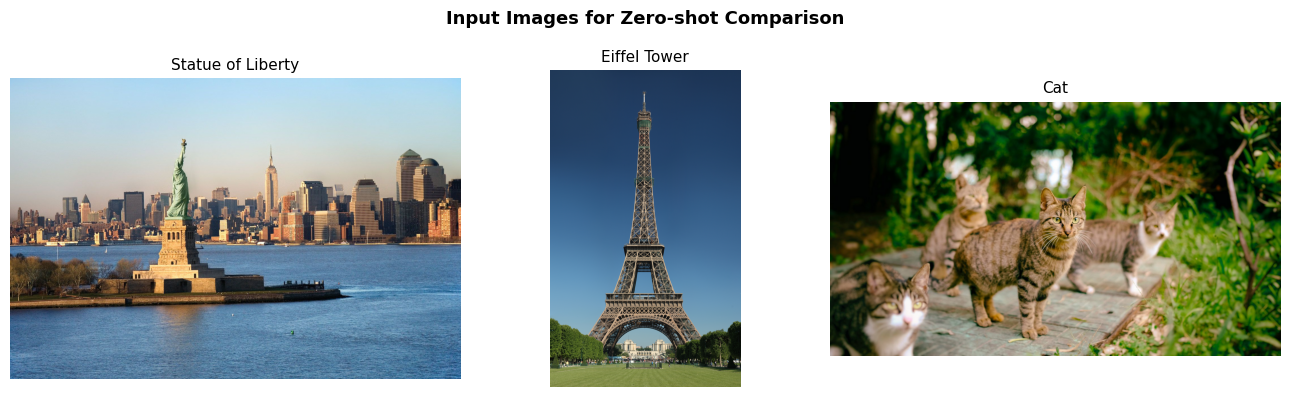

In [27]:
from pathlib import Path

# 자유의 여신상 — 강의와 동일한 URL
base_image = load_image(
    "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"
)
print(f"Statue of Liberty loaded: {base_image.size}")

# 에펠탑 / 고양이 — 프로젝트 images 폴더에서 로드
IMAGE_DIR = Path.home() / "project" / "VLM_2" / "images"

from PIL import Image
eiffel_image = Image.open(IMAGE_DIR / "eiffel.jpg").convert("RGB")
cat_image    = Image.open(IMAGE_DIR / "cats.jpg").convert("RGB")
print(f"Eiffel Tower loaded  : {eiffel_image.size}")
print(f"Cat loaded           : {cat_image.size}")

# zero-shot 비교용 이미지 dict
zeroshot_images = {
    "Statue of Liberty": base_image,
    "Eiffel Tower"     : eiffel_image,
    "Cat"              : cat_image,
}

# 미리보기
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, img) in zip(axes, zeroshot_images.items()):
    ax.imshow(img); ax.set_title(name, fontsize=11); ax.axis("off")
plt.suptitle("Input Images for Zero-shot Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Task (1): Prompt Variation Experiment

Same image, 3 different prompts — observe how caption changes.


Task (1): Prompt Variation — Statue of Liberty

[Prompt 1] Describe this image.
[Caption] The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to

[Prompt 2] What is happening in this image?
[Caption] The image depicts a large statue of the Statue of Liberty located on Liberty Island in New York City. The statue is a green, cylindrical statue of a woman holding a torch in her right hand and a crown in her left hand. The statue is situated on a small pedestal that is attached to the Liberty Island, which is a large, stone pedestal that is part of the Liberty Island Mu

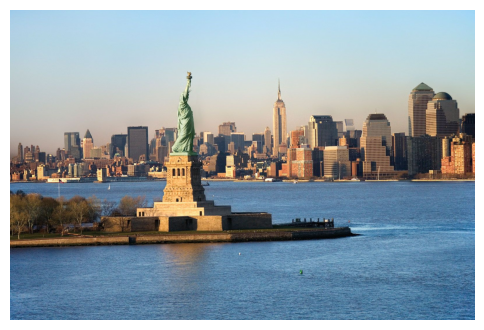

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to
---
image url(id): Prompt 2


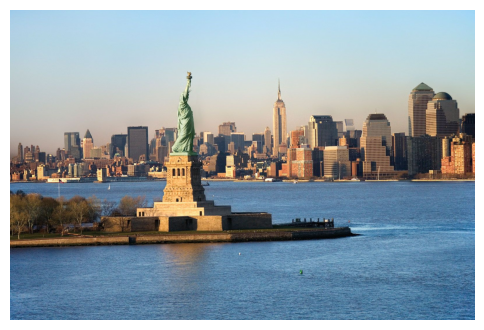

caption: The image depicts a large statue of the Statue of Liberty located on Liberty Island in New York City. The statue is a green, cylindrical statue of a woman holding a torch in her right hand and a crown in her left hand. The statue is situated on a small pedestal that is attached to the Liberty Island, which is a large, stone pedestal that is part of the Liberty Island Museum. The statue is surrounded by a large body of water, which is the Hudson River, and is surrounded
---
image url(id): Prompt 3


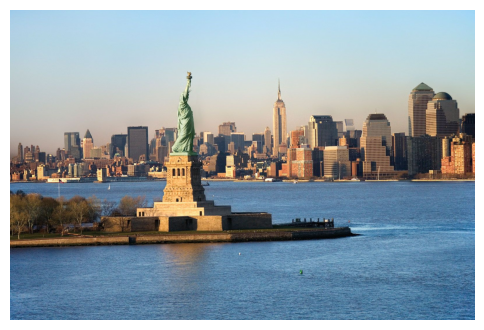

caption: In the foreground of the picture there is water. In the center of the picture there is a statue. In the background there are buildings, trees, boats and the sky.


In [28]:
prompts = [
    "Describe this image.",
    "What is happening in this image?",
    "Explain this image in one sentence.",
]

print("=" * 65)
print("Task (1): Prompt Variation — Statue of Liberty")
print("=" * 65)

samples_t1, captions_t1 = [], []
for i, prompt in enumerate(prompts, 1):
    print(f"\n[Prompt {i}] {prompt}")
    caption = generate_caption(base_image, prompt, max_new_tokens=100)
    print(f"[Caption] {caption}")
    samples_t1.append({"image": base_image, "caption": prompt, "filename": f"Prompt {i}"})
    captions_t1.append(caption)

print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t1,
    predicted_captions=captions_t1,
    caption_label="PROMPT",
    cols=3,
    title="Task (1): Same Image, Different Prompts",
    show=True,
)


In [29]:
print("=" * 65)
print("Comparison Summary")
print("=" * 65)
for i, (s, c) in enumerate(zip(samples_t1, captions_t1), 1):
    print(f"\nPrompt {i}: '{s['caption']}'")
    print(f"  -> {c}")

print("\n[Analysis]")
print("  - 'Describe this image.' generates a broad, general description of the scene.")
print("  - 'What is happening?' shifts focus toward actions/events rather than objects.")
print("  - 'Explain in one sentence.' produces the most concise, structured output.")
print("  - Same image yields different captions depending on prompt phrasing.")


Comparison Summary

Prompt 1: 'Describe this image.'
  -> The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to

Prompt 2: 'What is happening in this image?'
  -> The image depicts a large statue of the Statue of Liberty located on Liberty Island in New York City. The statue is a green, cylindrical statue of a woman holding a torch in her right hand and a crown in her left hand. The statue is situated on a small pedestal that is attached to the Liberty Island, which is a large, stone pedestal that is part of the Liberty Island Museum. The statue is surrounded by a 

---
## Task (2): Zero-shot Image Comparison

Same prompt applied to different images — observe how caption adapts.


Task (2): Zero-shot Image Comparison
Prompt: 'Describe this image in detail.'

[Image] Statue of Liberty
[Caption] The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body of water, which is the Hudson River.

The statue is made of bronze and is painted in a green color. It is a replica of the Statue of Liberty, which was originally built in

[Image] Eiffel Tower
[Caption] The image depicts the Eiffel Tower, a prominent landmark in Paris, France. The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green, and grassy plaza in Paris. The tower is 320 meters (1,984 feet) tall and is one of the most recognizable landmarks in the world.

### Description of 

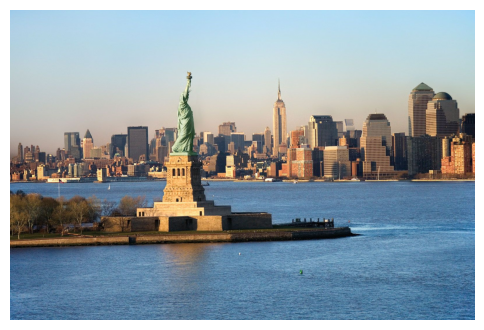

caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body of water, which is the Hudson River.

The statue is made of bronze and is painted in a green color. It is a replica of the Statue of Liberty, which was originally built in
---
image url(id): Eiffel Tower


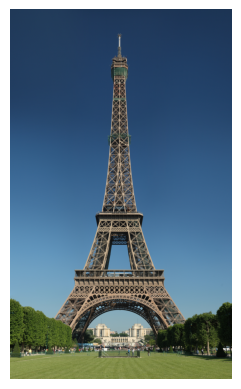

caption: The image depicts the Eiffel Tower, a prominent landmark in Paris, France. The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green, and grassy plaza in Paris. The tower is 320 meters (1,984 feet) tall and is one of the most recognizable landmarks in the world.

### Description of the Eiffel Tower:
1. **Structure and Design:**
   - **Eiffel Tower:** The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green
---
image url(id): Cat


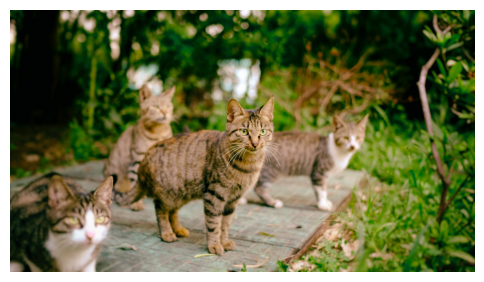

caption: The image depicts a group of four cats standing on a stone surface, which appears to be part of a garden or a park. The cats are of different breeds and sizes, with distinct patterns and colors. The background is blurred, focusing attention on the cats and the stone surface.

The cats are all standing close together, with their heads slightly turned towards the camera. They are all looking directly at the camera, which is a common behavior for cats to show when they are curious or interested in something. The cats have different fur patterns, including short, medium, and long fur. Some of


In [30]:
prompt_t2 = "Describe this image in detail."

print("=" * 65)
print(f"Task (2): Zero-shot Image Comparison")
print(f"Prompt: '{prompt_t2}'")
print("=" * 65)

samples_t2, captions_t2 = [], []
for name, img in zeroshot_images.items():
    print(f"\n[Image] {name}")
    caption = generate_caption(img, prompt_t2, max_new_tokens=120)
    print(f"[Caption] {caption}")
    samples_t2.append({"image": img, "caption": prompt_t2, "filename": name})
    captions_t2.append(caption)

print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t2,
    predicted_captions=captions_t2,
    caption_label="PROMPT",
    cols=len(samples_t2),
    title="Task (2): Zero-shot — Same Prompt, Different Images",
    show=True,
)


In [31]:
print("=" * 65)
print("Image-Caption Pair Summary")
print("=" * 65)
for s, c in zip(samples_t2, captions_t2):
    print(f"\n  Image  : {s['filename']}")
    print(f"  Caption: {c}")

print("\n[Analysis]")
print("  - Each image produces a distinctly different caption despite the same prompt.")
print("  - Statue of Liberty: focuses on landmark, island, and surrounding water.")
print("  - Eiffel Tower: focuses on the iconic structure and Parisian context.")
print("  - Cat: focuses on animal appearance, posture, and surroundings.")
print("  - The model correctly identifies the main subject in each image (zero-shot).")


Image-Caption Pair Summary

  Image  : Statue of Liberty
  Caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body of water, which is the Hudson River.

The statue is made of bronze and is painted in a green color. It is a replica of the Statue of Liberty, which was originally built in

  Image  : Eiffel Tower
  Caption: The image depicts the Eiffel Tower, a prominent landmark in Paris, France. The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars, a large, green, and grassy plaza in Paris. The tower is 320 meters (1,984 feet) tall and is one of the most recognizable landmarks in the world.

### Description of the Eiffel Tower:
1. **Structure and Design

---
## Task (3): Prompt Length Experiment

Short vs long prompt — does a more detailed prompt yield a richer caption?


Task (3): Prompt Length — Statue of Liberty

[Short] 'Describe.'
[Caption] The image depicts a large, historic statue of Liberty, located in New York City. The statue is a green, cylindrical statue of Liberty, which is the largest statue in the world. It is located on a small pedestal, which is attached to a tower that rises above the statue. The statue is surrounded by a large, open space, which is likely a plaza or a public square.

In the background, there are several tall buildings, including the Empire State Building, which is

[Long] 'Please describe this image carefully and explain what is happening in detail.'
[Caption] The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure of the statue. It is positioned atop a pedestal, which is supported by a cylindrical structure. The pedestal is supported by a series of columns, which are

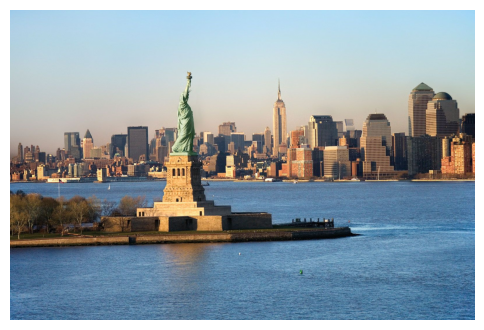

caption: The image depicts a large, historic statue of Liberty, located in New York City. The statue is a green, cylindrical statue of Liberty, which is the largest statue in the world. It is located on a small pedestal, which is attached to a tower that rises above the statue. The statue is surrounded by a large, open space, which is likely a plaza or a public square.

In the background, there are several tall buildings, including the Empire State Building, which is
---
image url(id): Long Prompt


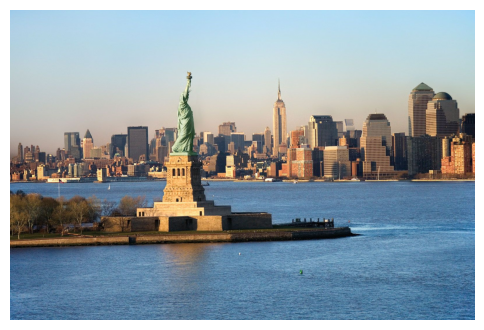

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure of the statue. It is positioned atop a pedestal, which is supported by a cylindrical structure. The pedestal is supported by a series of columns, which are visible in the image.

The statue is surrounded by a large, flat, and slightly curved roof, which

[Analysis]
  - Longer prompt guides the model toward a more detailed output.
  - Short 'Describe.' yields a brief, generic response.
  - Explicit instructions ('carefully', 'in detail') encourage richer descriptions.


In [32]:
prompt_short = "Describe."
prompt_long  = "Please describe this image carefully and explain what is happening in detail."

print("=" * 65)
print("Task (3): Prompt Length — Statue of Liberty")
print("=" * 65)

print(f"\n[Short] '{prompt_short}'")
caption_short = generate_caption(base_image, prompt_short, max_new_tokens=100)
print(f"[Caption] {caption_short}")

print(f"\n[Long] '{prompt_long}'")
caption_long = generate_caption(base_image, prompt_long, max_new_tokens=100)
print(f"[Caption] {caption_long}")

print(f"\n  Short word count : {len(caption_short.split())}")
print(f"  Long  word count : {len(caption_long.split())}")

samples_t3 = [
    {"image": base_image, "caption": f"Short: '{prompt_short}'",       "filename": "Short Prompt"},
    {"image": base_image, "caption": f"Long: '{prompt_long[:40]}...'", "filename": "Long Prompt"},
]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t3,
    predicted_captions=[caption_short, caption_long],
    caption_label="PROMPT",
    cols=2,
    title="Task (3): Prompt Length — Short vs Long",
    show=True,
)

print("\n[Analysis]")
print("  - Longer prompt guides the model toward a more detailed output.")
print("  - Short 'Describe.' yields a brief, generic response.")
print("  - Explicit instructions ('carefully', 'in detail') encourage richer descriptions.")


---
## Task (4): Question vs Command Prompt

Does phrasing as a question vs a command affect the output?


Task (4): Question vs Command — Statue of Liberty

[Question] 'What is in this image?'
[Caption] The image shows the Statue of Liberty, a green statue located on Liberty Island in New York City. The statue is surrounded by water and stands atop a small pedestal. In the background, there are many tall buildings, including the Empire State Building, which is visible in the distance. The sky is clear with a hint of sunlight breaking through the clouds, indicating it is a sunny day.

[Command] 'Describe this image.'
[Caption] The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and 

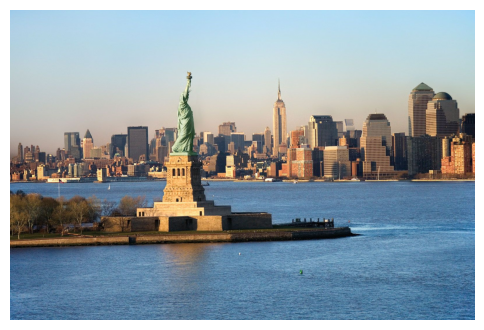

caption: The image shows the Statue of Liberty, a green statue located on Liberty Island in New York City. The statue is surrounded by water and stands atop a small pedestal. In the background, there are many tall buildings, including the Empire State Building, which is visible in the distance. The sky is clear with a hint of sunlight breaking through the clouds, indicating it is a sunny day.
---
image url(id): Command


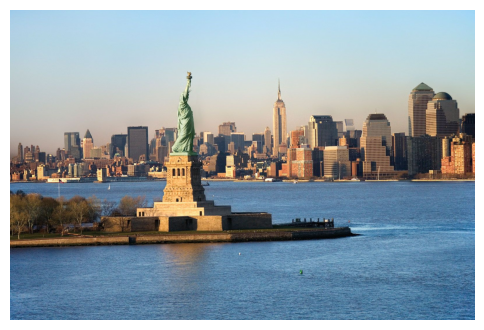

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical structure with a human figure atop it. The figure is depicted in a flowing, flowing pose, with the head and shoulders of the statue slightly tilted to the left, and the body slightly tilted to the right. The statue is mounted on a pedestal that is supported by a cylindrical structure, which is also green and appears to

[Analysis]
  - Question form tends to produce a direct, list-like answer.
  - Command form produces a more narrative, flowing description.
  - Both refer to the same subject but differ in structure and tone.


In [33]:
prompt_q = "What is in this image?"
prompt_c = "Describe this image."

print("=" * 65)
print("Task (4): Question vs Command — Statue of Liberty")
print("=" * 65)

print(f"\n[Question] '{prompt_q}'")
caption_q = generate_caption(base_image, prompt_q, max_new_tokens=100)
print(f"[Caption] {caption_q}")

print(f"\n[Command] '{prompt_c}'")
caption_c = generate_caption(base_image, prompt_c, max_new_tokens=100)
print(f"[Caption] {caption_c}")

samples_t4 = [
    {"image": base_image, "caption": f"Q: '{prompt_q}'", "filename": "Question"},
    {"image": base_image, "caption": f"C: '{prompt_c}'", "filename": "Command"},
]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t4,
    predicted_captions=[caption_q, caption_c],
    caption_label="PROMPT",
    cols=2,
    title="Task (4): Question vs Command Prompt",
    show=True,
)

print("\n[Analysis]")
print("  - Question form tends to produce a direct, list-like answer.")
print("  - Command form produces a more narrative, flowing description.")
print("  - Both refer to the same subject but differ in structure and tone.")


---
## Task (5): Caption Length Control

Control output length via `max_new_tokens` — 30 vs 80 tokens.


Task (5): Caption Length Control — Statue of Liberty
Prompt: 'Describe this image in detail.'

[max_new_tokens = 30]
[Caption] The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was  (words: 26)

[max_new_tokens = 80]
[Caption] The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body  (words: 69)

--- Caption Cards ---
---
image url(id): tokens=30 (words:26)


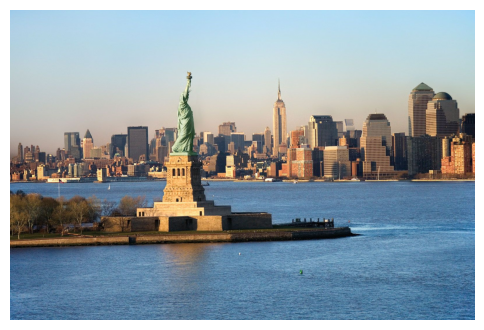

caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was
---
image url(id): tokens=80 (words:69)


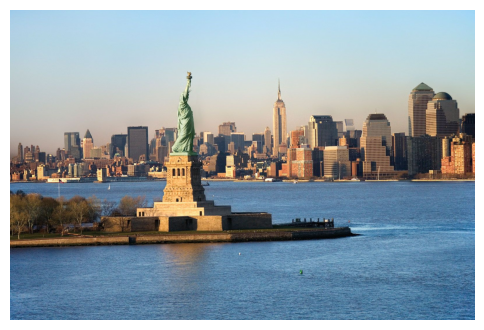

caption: The image depicts a large, historic statue of liberty, located in New York City. The statue is a replica of the Statue of Liberty, which was originally built in 1886 and is one of the most recognizable landmarks in the world. The statue is located on a small island in the Hudson River, which is a tributary of the Hudson River. The island is surrounded by a large body

[Analysis]
  - max_new_tokens=30: short summary, often cuts off mid-sentence.
  - max_new_tokens=80: more elaboration, richer scene details.
  - Shorter limit forces model to prioritize salient information.


In [34]:
prompt_t5 = "Describe this image in detail."

print("=" * 65)
print("Task (5): Caption Length Control — Statue of Liberty")
print("=" * 65)
print(f"Prompt: '{prompt_t5}'")

print(f"\n[max_new_tokens = 30]")
caption_30 = generate_caption(base_image, prompt_t5, max_new_tokens=30)
print(f"[Caption] {caption_30}  (words: {len(caption_30.split())})")

print(f"\n[max_new_tokens = 80]")
caption_80 = generate_caption(base_image, prompt_t5, max_new_tokens=80)
print(f"[Caption] {caption_80}  (words: {len(caption_80.split())})")

samples_t5 = [
    {"image": base_image, "caption": f"max_new_tokens=30", "filename": f"tokens=30 (words:{len(caption_30.split())})"},
    {"image": base_image, "caption": f"max_new_tokens=80", "filename": f"tokens=80 (words:{len(caption_80.split())})"},
]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t5,
    predicted_captions=[caption_30, caption_80],
    caption_label="SETTING",
    cols=2,
    title="Task (5): Caption Length Control",
    show=True,
)

print("\n[Analysis]")
print("  - max_new_tokens=30: short summary, often cuts off mid-sentence.")
print("  - max_new_tokens=80: more elaboration, richer scene details.")
print("  - Shorter limit forces model to prioritize salient information.")


---
## Task (6): Hallucination Observation

Use a complex image and check whether the model generates inaccurate information.


Task (6): Hallucination Observation
Image: Statue of Liberty (complex scene: statue + skyline + water + sky)
Prompt: 'Describe everything in the image accurately.'

[Caption]
  The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure in the image. It is positioned atop a pedestal, which is a cylindrical structure that supports the statue. The pedestal is supported by a series of columns, which are part of the statue's base.

The statue is surrounded by a large, flat, and slightly curved roof, which is likely a part of the building that houses the statue. The roof is made of a material that is not clearly visible, but it appears to be a combination of stone and metal.

In the background, there is a

--- Caption Cards ---
---
image url(id): Statue of Liberty


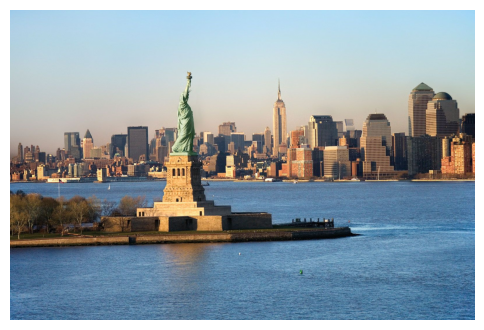

caption: The image depicts a large, historic statue of Liberty situated on a small island in a body of water, likely a river or a lake. The statue is a green, cylindrical statue of Liberty, which is the central figure in the image. It is positioned atop a pedestal, which is a cylindrical structure that supports the statue. The pedestal is supported by a series of columns, which are part of the statue's base.

The statue is surrounded by a large, flat, and slightly curved roof, which is likely a part of the building that houses the statue. The roof is made of a material that is not clearly visible, but it appears to be a combination of stone and metal.

In the background, there is a

[Hallucination Check]
  Visually present:
  + Statue of Liberty, NYC skyline, water, sky

  Potentially hallucinated:
  ? 'cylindrical statue'  -> not cylindrical 
  ? 'long, flowing hair'  -> she wears a crown 
  ? left/right hand swap  -> often incorrect 
  ? people/crowds         -> not visible 

  [Note

In [37]:
prompt_t6 = "Describe everything in the image accurately."

print("=" * 65)
print("Task (6): Hallucination Observation")
print("Image: Statue of Liberty (complex scene: statue + skyline + water + sky)")
print("=" * 65)
print(f"Prompt: '{prompt_t6}'")

caption_t6 = generate_caption(base_image, prompt_t6, max_new_tokens=150)
print(f"\n[Caption]\n  {caption_t6}")

samples_t6 = [{"image": base_image, "caption": prompt_t6, "filename": "Statue of Liberty"}]
print("\n--- Caption Cards ---")
show_caption_cards(
    samples_t6,
    predicted_captions=[caption_t6],
    caption_label="PROMPT",
    cols=1,
    title="Task (6): Hallucination Observation",
    show=True,
)

print("\n[Hallucination Check]")
print("  Visually present:")
print("  + Statue of Liberty, NYC skyline, water, sky")
print()
print("  Potentially hallucinated:")
print("  ? 'cylindrical statue'  -> not cylindrical ")
print("  ? 'long, flowing hair'  -> she wears a crown ")
print("  ? left/right hand swap  -> often incorrect ")
print("  ? people/crowds         -> not visible ")
print()
print("  [Note] Hallucination = plausible but visually unsupported details.")


---
## Overall Summary

In [36]:
print("=" * 65)
print("Part 3 — Overall Summary")
print("=" * 65)
print()
print("(1) Prompt Variation  : Same image, different prompts -> different style/focus")
print("(2) Zero-shot Images  : Same prompt, COCO images     -> model adapts per scene")
print("(3) Prompt Length     : Longer prompt -> more detailed output")
print("(4) Question vs Cmd   : Question -> direct answer, Command -> narrative")
print("(5) Length Control    : max_new_tokens controls verbosity")
print("(6) Hallucination     : Model generates plausible but inaccurate details")
print()
print("Key Takeaway:")
print("  Prompt engineering significantly affects VLM output quality and style.")


Part 3 — Overall Summary

(1) Prompt Variation  : Same image, different prompts -> different style/focus
(2) Zero-shot Images  : Same prompt, COCO images     -> model adapts per scene
(3) Prompt Length     : Longer prompt -> more detailed output
(4) Question vs Cmd   : Question -> direct answer, Command -> narrative
(5) Length Control    : max_new_tokens controls verbosity
(6) Hallucination     : Model generates plausible but inaccurate details

Key Takeaway:
  Prompt engineering significantly affects VLM output quality and style.
